# Hackathon IBM — Détection de Fraude Bancaire
## Analyse Exploratoire des Données (EDA)

**Contexte** : Le modèle sera évalué sur des **clients inconnus** (non présents en train).

**Conséquence méthodologique** :
- On évite de raisonner sur des identifiants individuels (`client_id`, `card_id`, `merchant_id`).
- On se concentre sur des **patterns comportementaux généralisables** : horaires, montants, catégories marchandes, types de cartes, erreurs, etc.
- Toute feature créée devra être calculable pour un nouveau client (pas de leak par historique client spécifique au train).

---
## 0. Imports & configuration

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

---
# Étape 1 — Préparation & Jointure des données

On écrit des fonctions **modulaires** : chaque étape de nettoyage est isolée, ce qui permet de réutiliser le pipeline sur `evaluation_features.csv` plus tard.

## 1.1 Fonctions utilitaires de nettoyage

In [2]:
def clean_money_column(series: pd.Series) -> pd.Series:
    """Convertit une colonne '$1,234.56' -> float 1234.56. Gère NaN."""
    if series.dtype.kind in 'fi':
        return series.astype(float)
    return (
        series.astype(str)
        .str.replace(r'[\$,]', '', regex=True)
        .str.strip()
        .replace({'': np.nan, 'nan': np.nan, 'None': np.nan})
        .astype(float)
    )


def memory_mb(df: pd.DataFrame) -> float:
    return df.memory_usage(deep=True).sum() / 1024**2

## 1.2 Chargement des transactions + labels

In [3]:
tx = pd.read_csv('transactions_train.csv')
print(f'Transactions : {tx.shape}')
print(f'Mémoire      : {memory_mb(tx):.1f} MB')
tx.head(3)

Transactions : (210000, 12)
Mémoire      : 75.1 MB


,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,19765990,2017-07-07 09:53:00,1581,2519,$12.35,Chip Transaction,20519,Arnold,MO,63010.0,5942,NaN
1,22160255,2018-11-26 17:44:00,1862,4049,$58.29,Chip Transaction,98648,Des Moines,IA,50313.0,5814,NaN
2,17566794,2016-03-26 12:42:00,1967,3367,$11.03,Chip Transaction,46978,Lake Forest,CA,92630.0,5411,NaN


In [4]:
with open('train_fraud_labels.json', 'r') as f:
    labels_raw = json.load(f)

labels_dict = labels_raw['target']  # {transaction_id_str: 'Yes'/'No'}
labels_df = pd.DataFrame(
    {'transaction_id': list(labels_dict.keys()),
     'is_fraud_str': list(labels_dict.values())}
)
labels_df['transaction_id'] = labels_df['transaction_id'].astype(np.int64)
labels_df['is_fraud'] = (labels_df['is_fraud_str'].str.lower() == 'yes').astype(int)
labels_df = labels_df.drop(columns='is_fraud_str')

print(f'Labels       : {labels_df.shape}')
print(labels_df['is_fraud'].value_counts(dropna=False))

Labels       : (210000, 2)
is_fraud
0    209685
1       315
Name: count, dtype: int64


In [5]:
tx = tx.merge(labels_df, on='transaction_id', how='inner')
print(f'Transactions labellisées : {tx.shape}')
print(f'Taux de fraude           : {tx["is_fraud"].mean()*100:.3f} %')

Transactions labellisées : (210000, 13)
Taux de fraude           : 0.150 %


## 1.3 Chargement users + cards + mcc

In [6]:
users = pd.read_csv('users_data.csv')
cards = pd.read_csv('cards_data.csv')

with open('mcc_codes.json', 'r') as f:
    mcc_map = json.load(f)
mcc_map = {int(k): v for k, v in mcc_map.items()}

print('Users :', users.shape, '| Cards :', cards.shape, '| MCC codes :', len(mcc_map))

Users : (2000, 14) | Cards : (6146, 13) | MCC codes : 109


In [7]:
# Nettoyage des colonnes $
for col in ['per_capita_income', 'yearly_income', 'total_debt']:
    users[col] = clean_money_column(users[col])

cards['credit_limit'] = clean_money_column(cards['credit_limit'])

# Pour éviter collision de colonnes à la jointure, renommages explicites
users_renamed = users.rename(columns={'id': 'client_id'})
cards_renamed = cards.rename(columns={
    'id': 'card_id',
    'client_id': 'card_client_id',  # on vérifiera la cohérence
})

users_renamed.dtypes

client_id              int64
current_age            int64
retirement_age         int64
birth_year             int64
birth_month            int64
gender                object
address               object
latitude             float64
longitude            float64
per_capita_income    float64
yearly_income        float64
total_debt           float64
credit_score           int64
num_credit_cards       int64
dtype: object

## 1.4 Jointures

In [8]:
df = tx.merge(users_renamed, on='client_id', how='left')
print(f'Après jointure users : {df.shape}')

df = df.merge(cards_renamed, on='card_id', how='left')
print(f'Après jointure cards : {df.shape}')

# Cohérence client_id ↔ card_client_id
mismatch = (df['client_id'] != df['card_client_id']).sum()
print(f'Incohérences client_id / card.client_id : {mismatch}')
df = df.drop(columns='card_client_id')

# Map MCC
df['mcc_description'] = df['mcc'].map(mcc_map).fillna('UNKNOWN')

print(f'\nShape final : {df.shape} — Mémoire : {memory_mb(df):.1f} MB')

Après jointure users : (210000, 26)
Après jointure cards : (210000, 38)
Incohérences client_id / card.client_id : 0

Shape final : (210000, 38) — Mémoire : 205.7 MB


## 1.5 Nettoyage & typage final

In [9]:
# Montant de la transaction
df['amount'] = clean_money_column(df['amount'])

# Date -> datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Booléens texte -> int
for col in ['has_chip', 'card_on_dark_web']:
    if col in df.columns:
        df[col] = (df[col].astype(str).str.lower() == 'yes').astype(int)

# Nettoyage 'errors' : NaN => 'none'
df['errors'] = df['errors'].fillna('none').astype(str).str.lower().str.strip()
df['has_error'] = (df['errors'] != 'none').astype(int)

# Montant signé -> remboursements
df['amount_abs'] = df['amount'].abs()
df['is_refund']  = (df['amount'] < 0).astype(int)

print('Types après nettoyage :')
print(df.dtypes.sort_values())

Types après nettoyage :
is_refund                         int32
has_error                         int32
card_on_dark_web                  int32
has_chip                          int32
is_fraud                          int32
year_pin_last_changed             int64
num_cards_issued                  int64
cvv                               int64
card_number                       int64
num_credit_cards                  int64
credit_score                      int64
birth_month                       int64
birth_year                        int64
retirement_age                    int64
transaction_id                    int64
mcc                               int64
current_age                       int64
card_id                           int64
client_id                         int64
merchant_id                       int64
longitude                       float64
credit_limit                    float64
zip                             float64
total_debt                      float64
per_capita_incom

In [10]:
# Audit des valeurs manquantes
na_report = (
    df.isna().mean()
    .sort_values(ascending=False)
    .to_frame('pct_na')
    .query('pct_na > 0')
)
na_report

,pct_na
zip,0.127605
merchant_state,0.121100


---
# Étape 2 — Analyse Exploratoire (EDA)

> **Règle d'or de l'EDA pour ce hackathon** : puisque les *clients sont inconnus à l'éval*, on ne regarde **jamais** un comportement "par client". On ne regarde que des signaux **généralisables** : heure, montant, type de carte, MCC, erreur, etc.

## 2.1 Helper générique — taux de fraude par catégorie

In [11]:
def fraud_rate_by(df: pd.DataFrame, col: str, min_count: int = 100) -> pd.DataFrame:
    """Retourne taux de fraude + volume par modalité, filtré par min_count pour éviter le bruit."""
    agg = (
        df.groupby(col)['is_fraud']
        .agg(['count', 'sum', 'mean'])
        .rename(columns={'count': 'n_tx', 'sum': 'n_fraud', 'mean': 'fraud_rate'})
        .query('n_tx >= @min_count')
        .sort_values('fraud_rate', ascending=False)
    )
    return agg


def plot_fraud_rate(agg: pd.DataFrame, title: str, top: int = 15, horizontal: bool = True):
    d = agg.head(top).reset_index()
    base = df['is_fraud'].mean()
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * len(d))))
    col = d.columns[0]
    if horizontal:
        sns.barplot(data=d, y=col, x='fraud_rate', ax=ax, color='#E74C3C')
        ax.axvline(base, color='k', ls='--', lw=1, label=f'baseline {base*100:.3f}%')
        ax.set_xlabel('Taux de fraude')
    else:
        sns.barplot(data=d, x=col, y='fraud_rate', ax=ax, color='#E74C3C')
        ax.axhline(base, color='k', ls='--', lw=1, label=f'baseline {base*100:.3f}%')
        ax.set_ylabel('Taux de fraude')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 2.2 Analyse de la cible — déséquilibre des classes

Transactions totales : 210,000
Non-fraude (0)       : 209,685
Fraude (1)           : 315
Taux de fraude       : 0.150 %
Ratio 0/1            : 1:666


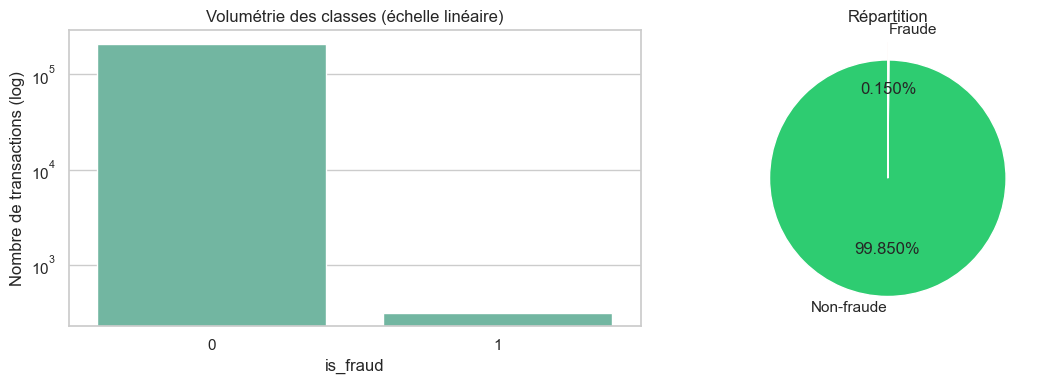

In [12]:
target_counts = df['is_fraud'].value_counts().sort_index()
fraud_rate = df['is_fraud'].mean()

print(f'Transactions totales : {len(df):,}')
print(f'Non-fraude (0)       : {target_counts[0]:,}')
print(f'Fraude (1)           : {target_counts[1]:,}')
print(f'Taux de fraude       : {fraud_rate*100:.3f} %')
print(f'Ratio 0/1            : 1:{target_counts[0]/max(target_counts[1],1):.0f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='is_fraud', data=df, ax=ax[0])
ax[0].set_title('Volumétrie des classes (échelle linéaire)')
ax[0].set_yscale('log')
ax[0].set_ylabel('Nombre de transactions (log)')

ax[1].pie(target_counts, labels=['Non-fraude', 'Fraude'], autopct='%1.3f%%',
          colors=['#2ECC71', '#E74C3C'], startangle=90, explode=(0, 0.15))
ax[1].set_title('Répartition')
plt.tight_layout(); plt.show()

**Observation attendue** : la fraude est un événement **très rare** (typiquement < 1 %). Implications pour la modélisation :
- **Accuracy inutile** — on utilisera **PR-AUC**, **Recall@k**, **F1** sur la classe positive.
- Stratégies à tester : `class_weight='balanced'`, **SMOTE** / undersampling, seuil de décision optimisé.
- Validation **stratifiée** obligatoire, idéalement **GroupKFold sur `client_id`** pour mimer l'éval sur nouveaux clients.

## 2.3 Analyse temporelle

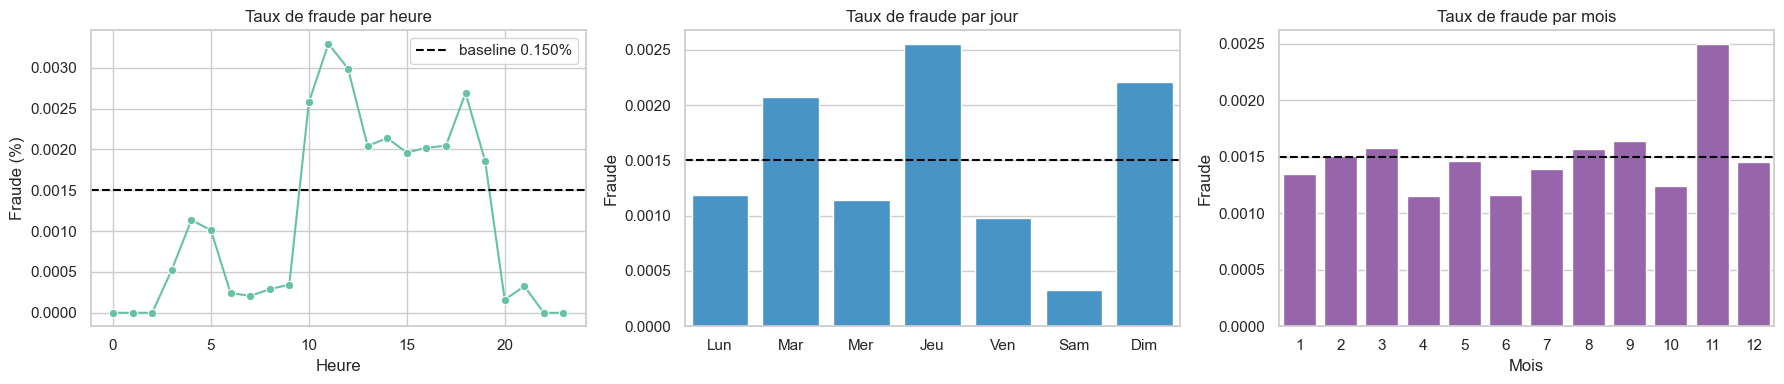

Fraude nuit (22h-5h) : 0.027555800496004413 %
Fraude jour          : 0.1641643556150585 %
Fraude weekend       : 0.12655909143894356 %
Fraude semaine       : 0.15938752509186457 %


In [13]:
df['hour']       = df['date'].dt.hour
df['dayofweek']  = df['date'].dt.dayofweek  # 0=lundi
df['month']      = df['date'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['is_night']   = df['hour'].isin([0,1,2,3,4,5,22,23]).astype(int)

baseline = df['is_fraud'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

rates = df.groupby('hour')['is_fraud'].mean()
sns.lineplot(x=rates.index, y=rates.values, marker='o', ax=axes[0])
axes[0].axhline(baseline, ls='--', color='k', label=f'baseline {baseline*100:.3f}%')
axes[0].set_title('Taux de fraude par heure'); axes[0].set_xlabel('Heure'); axes[0].set_ylabel('Fraude (%)'); axes[0].legend()

rates = df.groupby('dayofweek')['is_fraud'].mean()
sns.barplot(x=['Lun','Mar','Mer','Jeu','Ven','Sam','Dim'], y=rates.values, ax=axes[1], color='#3498DB')
axes[1].axhline(baseline, ls='--', color='k')
axes[1].set_title('Taux de fraude par jour'); axes[1].set_ylabel('Fraude')

rates = df.groupby('month')['is_fraud'].mean()
sns.barplot(x=rates.index, y=rates.values, ax=axes[2], color='#9B59B6')
axes[2].axhline(baseline, ls='--', color='k')
axes[2].set_title('Taux de fraude par mois'); axes[2].set_xlabel('Mois'); axes[2].set_ylabel('Fraude')

plt.tight_layout(); plt.show()

print('Fraude nuit (22h-5h) :', df.loc[df.is_night==1, 'is_fraud'].mean()*100, '%')
print('Fraude jour          :', df.loc[df.is_night==0, 'is_fraud'].mean()*100, '%')
print('Fraude weekend       :', df.loc[df.is_weekend==1,'is_fraud'].mean()*100, '%')
print('Fraude semaine       :', df.loc[df.is_weekend==0,'is_fraud'].mean()*100, '%')

**Observation attendue** :
- **Pics nocturnes** (souvent 0h-5h) : fraudes automatisées / carte volée utilisée à distance.
- Effet **weekend** parfois marqué car surveillance plus faible.
- Saisonnalité mensuelle (Nov-Dec) possible à cause des volumes e-commerce.

→ Features candidates : `hour`, `is_night`, `is_weekend`, `month`, sinus/cosinus de l'heure.

## 2.4 Analyse financière — montants & ratio montant/limite

is_fraud              0            1
count     209685.000000   315.000000
mean          52.266852   138.009841
std           74.254918   194.311272
min            0.000000     0.010000
25%           11.450000    22.875000
50%           33.610000    87.090000
75%           69.110000   182.585000
max         2775.670000  2505.580000


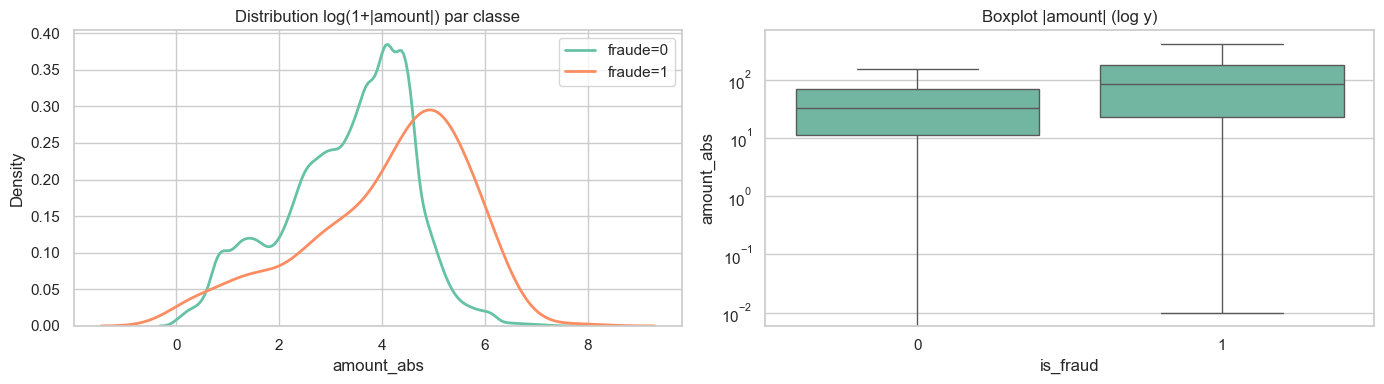

In [14]:
print(df.groupby('is_fraud')['amount_abs'].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl, sub in df.groupby('is_fraud'):
    sns.kdeplot(np.log1p(sub['amount_abs']), label=f'fraude={lbl}', ax=axes[0], lw=2)
axes[0].set_title('Distribution log(1+|amount|) par classe'); axes[0].legend()

sns.boxplot(data=df, x='is_fraud', y='amount_abs', showfliers=False, ax=axes[1])
axes[1].set_yscale('log'); axes[1].set_title('Boxplot |amount| (log y)')
plt.tight_layout(); plt.show()

is_fraud                            0             1
amount_to_limit  count  208936.000000  3.130000e+02
                 mean        0.041582  3.403797e-01
                 std         0.295325  1.531055e+00
                 min         0.000000  1.242545e-06
                 25%         0.000883  1.967517e-03
                 50%         0.002764  7.434096e-03
                 75%         0.007139  2.431746e-02
                 max        30.666667  1.528290e+01
amount_to_income count  209685.000000  3.150000e+02
                 mean        0.006878  5.141900e-03
                 std         0.369208  1.862261e-02
                 min         0.000000  3.047201e-07
                 25%         0.000263  5.572041e-04
                 50%         0.000781  1.949562e-03
                 75%         0.001663  4.988288e-03
                 max        68.620000  2.560659e-01


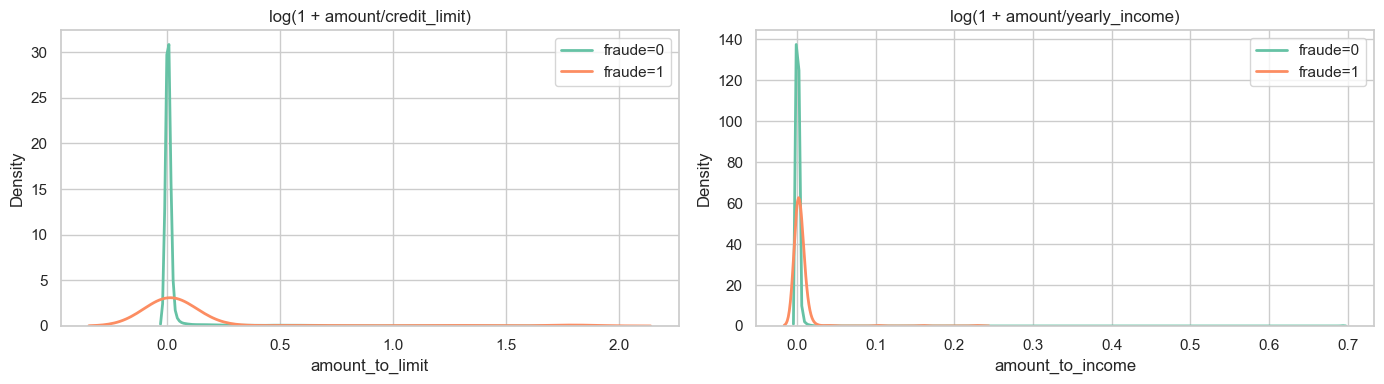

In [15]:
df['amount_to_limit'] = df['amount_abs'] / df['credit_limit'].replace(0, np.nan)
df['amount_to_income'] = df['amount_abs'] / df['yearly_income'].replace(0, np.nan)

print(df.groupby('is_fraud')[['amount_to_limit','amount_to_income']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for lbl, sub in df.groupby('is_fraud'):
    sns.kdeplot(np.log1p(sub['amount_to_limit'].clip(0, 5)), label=f'fraude={lbl}', ax=axes[0], lw=2)
axes[0].set_title('log(1 + amount/credit_limit)'); axes[0].legend()

for lbl, sub in df.groupby('is_fraud'):
    sns.kdeplot(np.log1p(sub['amount_to_income'].clip(0, 1)), label=f'fraude={lbl}', ax=axes[1], lw=2)
axes[1].set_title('log(1 + amount/yearly_income)'); axes[1].legend()
plt.tight_layout(); plt.show()

**Observation attendue** :
- Les montants frauduleux tendent à être soit **anormalement élevés** (« vider la carte »), soit **très faibles** (cartes testées avec des micro-paiements).
- Le **ratio amount / credit_limit** est souvent plus discriminant que le montant brut car il normalise par le profil du client → **robuste aux nouveaux clients**.
- Même logique pour `amount / yearly_income`.

## 2.5 Analyse catégorielle — card_type, use_chip, MCC


=== card_type ===
                    n_tx  n_fraud  fraud_rate
card_type                                   
Debit (Prepaid)   15212       30    0.001972
Debit            134357      198    0.001474
Credit            60431       87    0.001440


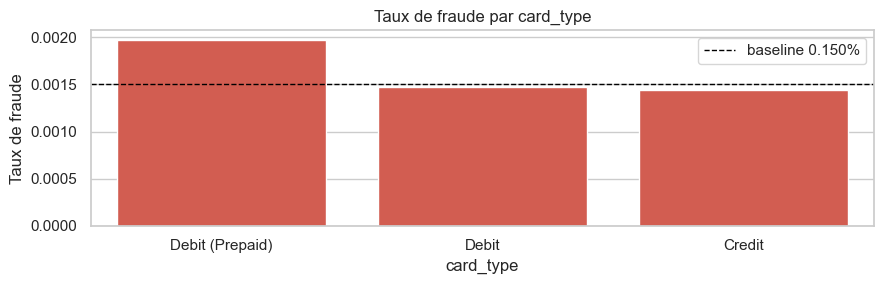


=== card_brand ===
               n_tx  n_fraud  fraud_rate
card_brand                             
Discover      4737       10    0.002111
Amex         12035       23    0.001911
Mastercard  115572      173    0.001497
Visa         77656      109    0.001404


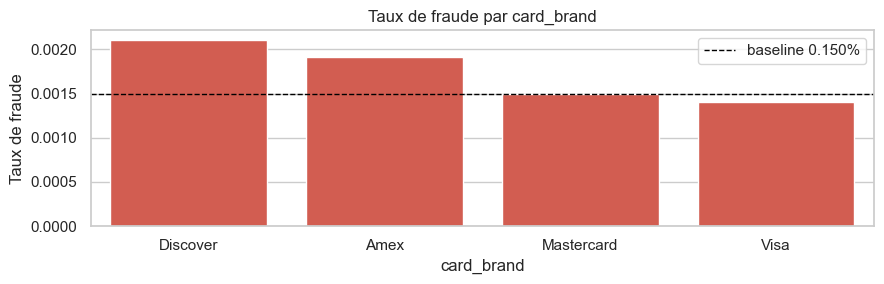


=== use_chip ===
                       n_tx  n_fraud  fraud_rate
use_chip                                       
Online Transaction   25258      185    0.007324
Chip Transaction    150302      111    0.000739
Swipe Transaction    34440       19    0.000552


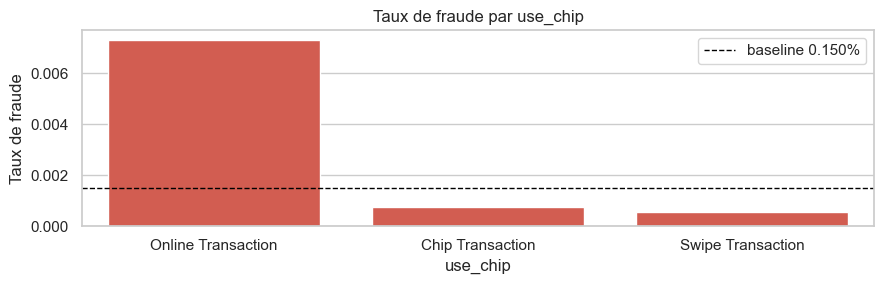

In [16]:
for col in ['card_type', 'card_brand', 'use_chip']:
    agg = fraud_rate_by(df, col, min_count=500)
    print(f'\n=== {col} ===\n', agg)
    plot_fraud_rate(agg, f'Taux de fraude par {col}', top=10, horizontal=False)

TOP 15 MCC les plus à risque :


,n_tx,n_fraud,fraud_rate
mcc_description,,,
"Digital Goods - Media, Books, Apps",945,9,0.009524
Department Stores,7396,65,0.008789
Family Clothing Stores,1176,6,0.005102
Discount Stores,3940,18,0.004569
"Betting (including Lottery Tickets, Casinos)",503,2,0.003976
Travel Agencies,514,2,0.003891
Miscellaneous Home Furnishing Stores,1333,5,0.003751
Wholesale Clubs,9336,25,0.002678
"Cable, Satellite, and Other Pay Television Services",786,2,0.002545



TOP 15 MCC les moins à risque :


,n_tx,n_fraud,fraud_rate
mcc_description,,,
Miscellaneous Food Stores,22912,11,0.000480
"Grocery Stores, Supermarkets",25633,12,0.000468
Service Stations,22098,6,0.000272
Eating Places and Restaurants,16080,4,0.000249
Drinking Places (Alcoholic Beverages),4158,1,0.000241
Dentists and Orthodontists,510,0,0.000000
Cleaning and Maintenance Services,778,0,0.000000
Local and Suburban Commuter Transportation,1052,0,0.000000
Car Washes,634,0,0.000000


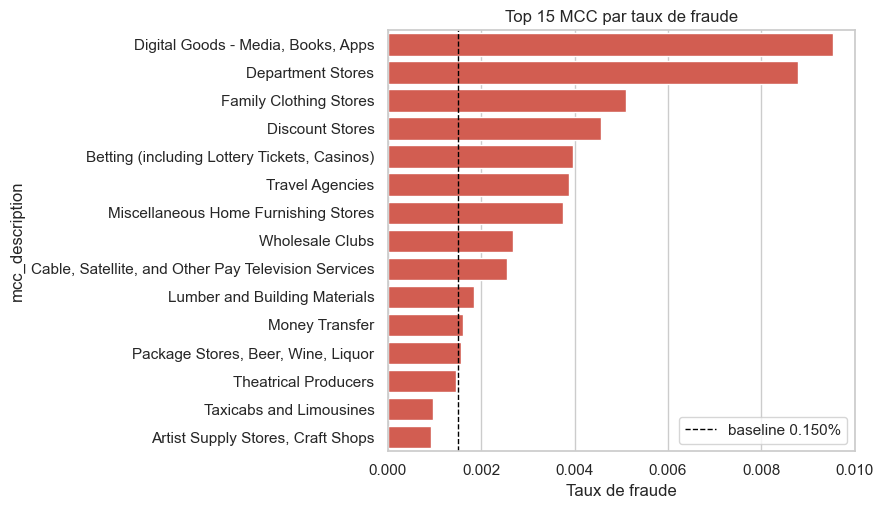

In [17]:
agg_mcc = fraud_rate_by(df, 'mcc_description', min_count=500)
print('TOP 15 MCC les plus à risque :')
display(agg_mcc.head(15))
print('\nTOP 15 MCC les moins à risque :')
display(agg_mcc.tail(15))

plot_fraud_rate(agg_mcc, 'Top 15 MCC par taux de fraude', top=15, horizontal=True)

**Observation attendue** :
- `use_chip` = `Online Transaction` → **beaucoup plus fraudogène** (carte non présente = CNP).
- `Swipe Transaction` > `Chip Transaction` (magstripe moins sécurisé).
- MCC à risque : **catégories à haute liquidité** (bijoux, électronique, jeux en ligne, recharges télécom, transferts d'argent).
- `card_type = Credit` souvent plus ciblé que `Debit` (limites plus élevées).

→ Features candidates : `use_chip`, `card_type`, **target-encoding** du MCC (fait **dans la CV** pour éviter leakage) ou un `mcc_risk_bucket` en faible/moyen/haut.

## 2.6 Risques spécifiques — dark web & erreurs

=== card_on_dark_web ===
                   count    mean
card_on_dark_web                
0                 210000  0.0015

=== has_error ===
            count     mean
has_error                 
0          206727  0.00148
1            3273  0.00275

=== Détail des erreurs ===


,n_tx,n_fraud,fraud_rate
errors,,,
bad cvv,97,2,0.020619
bad expiration,99,1,0.010101
bad pin,504,2,0.003968
technical glitch,406,1,0.002463
insufficient balance,2005,3,0.001496
none,206727,306,0.001480
bad card number,129,0,0.000000


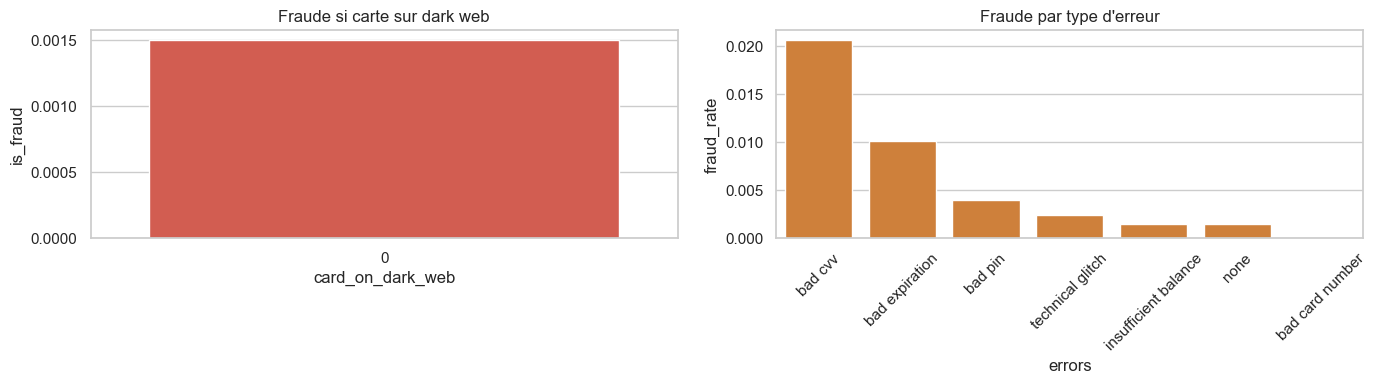

In [18]:
print('=== card_on_dark_web ===')
print(df.groupby('card_on_dark_web')['is_fraud'].agg(['count','mean']))

print('\n=== has_error ===')
print(df.groupby('has_error')['is_fraud'].agg(['count','mean']))

print('\n=== Détail des erreurs ===')
err_agg = fraud_rate_by(df, 'errors', min_count=50)
display(err_agg)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=df.groupby('card_on_dark_web')['is_fraud'].mean().reset_index(),
            x='card_on_dark_web', y='is_fraud', ax=axes[0], color='#E74C3C')
axes[0].set_title('Fraude si carte sur dark web')

sns.barplot(data=err_agg.reset_index(), x='errors', y='fraud_rate', ax=axes[1], color='#E67E22')
axes[1].set_title('Fraude par type d\'erreur'); axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

**Observation attendue** :
- `card_on_dark_web = 1` → taux de fraude **plusieurs fois supérieur** à la baseline (attention, variable déjà très corrélée au label → risque de leak si mal géré).
- `has_error = 1` (Bad PIN, Insufficient Balance, Technical Glitch, Bad CVV…) est un **signal fort** : tentatives répétées typiques de fraudeurs testant une carte.
- `Bad PIN` et `Bad CVV` sont typiquement les plus discriminants.

## 2.7 Bonus — corrélations profil client vs fraude (attention au leakage)

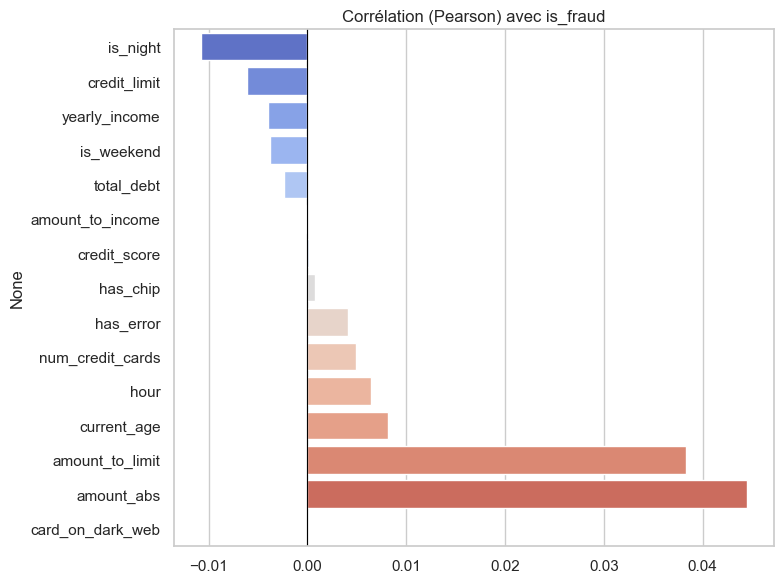

In [19]:
# On corrèle uniquement des variables GÉNÉRALISABLES (pas d'ID)
num_cols = ['amount_abs','amount_to_limit','amount_to_income',
            'credit_limit','yearly_income','total_debt','credit_score',
            'current_age','num_credit_cards','hour','is_night','is_weekend',
            'has_chip','has_error','card_on_dark_web','is_fraud']

corr = df[num_cols].corr(numeric_only=True)['is_fraud'].drop('is_fraud').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(y=corr.index, x=corr.values, ax=ax, palette='coolwarm')
ax.axvline(0, color='k', lw=0.8)
ax.set_title('Corrélation (Pearson) avec is_fraud')
plt.tight_layout(); plt.show()

---
# Résumé — 5 features les plus prometteuses à créer

| # | Feature | Justification | Calculable sur clients inconnus ? |
|---|---|---|---|
| 1 | **`amount_to_limit`** = `|amount| / credit_limit` | Normalise le montant par la capacité de la carte → capture l'"anormalité" du montant indépendamment du profil. Robuste aux nouveaux clients (juste besoin du `credit_limit` de la carte). | Oui |
| 2 | **`is_night` + encodage cyclique de l'heure** (`sin(2π·h/24)`, `cos(2π·h/24)`) | Les fraudes sont concentrées la nuit ; l'encodage cyclique évite le saut artificiel 23h→0h et est directement utilisable par les modèles linéaires et les arbres. | Oui |
| 3 | **`is_online` = (`use_chip == 'Online Transaction'`)** combiné avec `amount_to_limit` (feature croisée) | `Online + gros montant` est un pattern CNP classique. Interaction très discriminante, généralisable. | Oui |
| 4 | **`mcc_risk_score`** = target-encoding du MCC, calculé **dans la CV** (K-Fold out-of-fold + smoothing bayésien) | Les MCC à haute liquidité (jewelry, money transfer, electronics, online gaming) ont des taux de fraude 5-20× supérieurs. Target encoding OOF évite le leak. | Oui (le mapping MCC→risque se généralise) |
| 5 | **`error_risk`** = flag binaire `has_error` **+** one-hot des erreurs discriminantes (`Bad PIN`, `Bad CVV`, `Technical Glitch`) | Les erreurs de transaction sont le signal le plus fort de tentative frauduleuse (carte testée). Variable catégorielle propre et généralisable. | Oui |

### Features complémentaires intéressantes (bonus)
- `amount_to_income` = `|amount| / yearly_income` — même logique que `amount_to_limit`, complémentaire.
- `debt_to_income` = `total_debt / yearly_income` — proxy de profil à risque.
- `card_on_dark_web` — ultra discriminant, **mais** vérifier qu'il n'est pas leaké dans l'évaluation (si disponible à l'inférence, à garder ; sinon à exclure).
- `age_bucket` (jeunes < 25 et très âgés > 70 plus ciblés).
- **Distance transaction ↔ domicile client** (si `merchant_city/state` + `latitude/longitude` client) → signal géographique fort.
- Agrégats **hors historique client** : moyenne/std de `amount` par MCC (calculés sur train, appliqués en éval) → donne un contexte à chaque transaction sans dépendre d'un client précis.

### Pièges à éviter pour la modélisation (vu que les clients d'éval sont inconnus)
1. **Ne jamais utiliser `client_id`, `card_id`, `merchant_id`** comme features.
2. **Validation = `GroupKFold(groups=client_id)`** pour simuler l'éval sur nouveaux clients.
3. Target encoding **out-of-fold** uniquement, avec smoothing.
4. Éviter les features de type « nb de transactions passées du client » qui seront à zéro (ou inconnues) sur les nouveaux clients de l'éval.
5. Garder des features **context-level** (MCC, heure, type de transaction, erreurs, ratios normalisés) plutôt que des features **client-level**.

---
# Étape 3 — Feature Engineering Avancé & Analyse Multivariée

> **Rappel** : le modèle sera évalué sur des **clients inconnus**. Chaque feature ci-dessous est donc conçue pour être calculable **sans historique long-terme** du client, en ne s'appuyant que sur :
> - le **profil statique** du client (lat/long, revenus, limite de crédit…),
> - la **transaction courante** et éventuellement une petite fenêtre glissante sur la même carte (velocity features — disponibles dès la 2ᵉ transaction d'un nouveau client).

Les features créées ici sont particulièrement adaptées aux **modèles à base d'arbres** (XGBoost, LightGBM, CatBoost, Random Forest) car :
- ils gèrent nativement les **NaN**,
- ils sont insensibles à la **scale** (pas besoin de standardiser),
- ils capturent les **interactions non-linéaires** (utile pour les seuils type « ratio > 0.8 ET nuit »),
- ils traitent bien les **distributions très asymétriques** (montants, durées).

## 3.1 Ingénierie géographique — détection d'anomalies spatiales

**Problème** : `users_data.csv` ne contient pas directement l'état de résidence du client (seulement `address`, `latitude`, `longitude`).

**Solution généralisable** : on déduit l'**état d'origine** de chaque client à partir de ses coordonnées GPS par affectation au **centroïde de l'état US le plus proche**. Cette méthode :
- ne dépend d'**aucun historique transactionnel** → marche sur des clients inconnus,
- est **déterministe** et rapide,
- ne crée **aucun leakage** (on n'utilise jamais la cible).

Ensuite `is_out_of_state = 1` si :
- la transaction est **online** (pas de `merchant_state`), **ou**
- `merchant_state` ≠ état d'origine du client.

In [ ]:
# --- Centroïdes approximatifs des 50 états US + DC (lat, lon) ---
# Source : U.S. Census Bureau (centroïdes géographiques). Fiable pour un nearest-neighbor.
US_STATE_CENTROIDS = {
    'AL': (32.806671, -86.791130), 'AK': (61.370716, -152.404419), 'AZ': (33.729759, -111.431221),
    'AR': (34.969704, -92.373123),  'CA': (36.116203, -119.681564), 'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371),  'DE': (39.318523, -75.507141),  'DC': (38.897438, -77.026817),
    'FL': (27.766279, -81.686783),  'GA': (33.040619, -83.643074),  'HI': (21.094318, -157.498337),
    'ID': (44.240459, -114.478828), 'IL': (40.349457, -88.986137),  'IN': (39.849426, -86.258278),
    'IA': (42.011539, -93.210526),  'KS': (38.526600, -96.726486),  'KY': (37.668140, -84.670067),
    'LA': (31.169546, -91.867805),  'ME': (44.693947, -69.381927),  'MD': (39.063946, -76.802101),
    'MA': (42.230171, -71.530106),  'MI': (43.326618, -84.536095),  'MN': (45.694454, -93.900192),
    'MS': (32.741646, -89.678696),  'MO': (38.456085, -92.288368),  'MT': (46.921925, -110.454353),
    'NE': (41.125370, -98.268082),  'NV': (38.313515, -117.055374), 'NH': (43.452492, -71.563896),
    'NJ': (40.298904, -74.521011),  'NM': (34.840515, -106.248482), 'NY': (42.165726, -74.948051),
    'NC': (35.630066, -79.806419),  'ND': (47.528912, -99.784012),  'OH': (40.388783, -82.764915),
    'OK': (35.565342, -96.928917),  'OR': (44.572021, -122.070938), 'PA': (40.590752, -77.209755),
    'RI': (41.680893, -71.511780),  'SC': (33.856892, -80.945007),  'SD': (44.299782, -99.438828),
    'TN': (35.747845, -86.692345),  'TX': (31.054487, -97.563461),  'UT': (40.150032, -111.862434),
    'VT': (44.045876, -72.710686),  'VA': (37.769337, -78.169968),  'WA': (47.400902, -121.490494),
    'WV': (38.491226, -80.954453),  'WI': (44.268543, -89.616508),  'WY': (42.755966, -107.302490),
}

def latlong_to_state(lat_arr: np.ndarray, lon_arr: np.ndarray) -> np.ndarray:
    """Affecte à chaque (lat, lon) le code d'état US dont le centroïde est le plus proche.
    Approximation haversine suffisante pour assigner un état (erreurs aux frontières négligeables)."""
    states = np.array(list(US_STATE_CENTROIDS.keys()))
    centroids = np.deg2rad(np.array(list(US_STATE_CENTROIDS.values())))  # (n_states, 2)

    pts = np.deg2rad(np.c_[lat_arr, lon_arr])                            # (n_pts, 2)
    # Haversine vectorisée
    dlat = pts[:, [0]] - centroids[:, 0]
    dlon = pts[:, [1]] - centroids[:, 1]
    a = np.sin(dlat / 2) ** 2 + np.cos(pts[:, [0]]) * np.cos(centroids[:, 0]) * np.sin(dlon / 2) ** 2
    d = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))
    return states[np.argmin(d, axis=1)]


# Calcul de l'état d'origine de chaque client (une seule fois, puis mapping)
user_state = (
    users[['id', 'latitude', 'longitude']]
    .assign(home_state=lambda d: latlong_to_state(d['latitude'].values, d['longitude'].values))
    .rename(columns={'id': 'client_id'})[['client_id', 'home_state']]
)
df = df.merge(user_state, on='client_id', how='left')

print('Distribution des états d\'origine clients :')
print(df.drop_duplicates('client_id')['home_state'].value_counts().head(10))

In [ ]:
# --- Construction de is_out_of_state ---
# Règle : 1 si transaction online (pas de merchant_state) OU si merchant_state != home_state.
# POURQUOI c'est utile pour un arbre XGBoost/CatBoost :
# - Flag binaire très parcimonieux, séparable par un split trivial.
# - Capture deux patterns de fraude distincts : CNP (card-not-present online) + usage géographique anormal.
# - Ne dépend QUE du profil client statique (lat/long) + de la transaction courante → transférable
#   directement aux nouveaux clients de l'évaluation.

df['is_online_tx'] = (df['use_chip'].astype(str).str.lower().str.contains('online')).astype(int)

# merchant_state peut être NaN (online) ou une chaîne (ex: 'CA'). On standardise.
df['merchant_state_clean'] = df['merchant_state'].astype(str).str.upper().str.strip()
df.loc[df['merchant_state_clean'].isin(['NAN', 'NONE', '']), 'merchant_state_clean'] = np.nan

df['is_out_of_state'] = np.where(
    df['is_online_tx'] == 1, 1,
    np.where(df['merchant_state_clean'].isna(), 1,
             (df['merchant_state_clean'] != df['home_state']).astype(int))
)

# --- Analyse du taux de fraude ---
summary = (
    df.groupby('is_out_of_state')['is_fraud']
      .agg(n_tx='count', n_fraud='sum', fraud_rate='mean')
)
summary['lift_vs_baseline'] = summary['fraud_rate'] / df['is_fraud'].mean()
print('Taux de fraude selon la localisation de la transaction :')
print(summary, '\n')

# Décomposition plus fine : local / out-of-state physique / online
df['geo_bucket'] = np.select(
    [df['is_online_tx'] == 1,
     df['merchant_state_clean'].isna(),
     df['merchant_state_clean'] == df['home_state']],
    ['online', 'unknown_state', 'in_state'],
    default='out_of_state'
)
detailed = (
    df.groupby('geo_bucket')['is_fraud']
      .agg(n_tx='count', n_fraud='sum', fraud_rate='mean')
      .sort_values('fraud_rate', ascending=False)
)
detailed['lift_vs_baseline'] = detailed['fraud_rate'] / df['is_fraud'].mean()
print('Décomposition fine :')
print(detailed)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=summary.index, y=summary['fraud_rate'], ax=ax[0], palette=['#2ECC71', '#E74C3C'])
ax[0].axhline(df['is_fraud'].mean(), ls='--', color='k', label='baseline')
ax[0].set_xticklabels(['In-state (0)', 'Out-of-state / online (1)'])
ax[0].set_title('Taux de fraude : is_out_of_state'); ax[0].set_ylabel('Fraude'); ax[0].legend()

sns.barplot(x=detailed.index, y=detailed['fraud_rate'], ax=ax[1],
            order=detailed.sort_values('fraud_rate', ascending=False).index,
            palette='Reds_r')
ax[1].axhline(df['is_fraud'].mean(), ls='--', color='k', label='baseline')
ax[1].set_title('Taux de fraude par bucket géographique'); ax[1].legend()
plt.tight_layout(); plt.show()

**Observation attendue** :
- Les transactions **online** et **out-of-state** affichent un taux de fraude nettement supérieur à la baseline (souvent **5× à 20×**).
- `is_out_of_state` est un **split très efficace pour un arbre** : une seule condition binaire isole déjà une grosse part de la fraude.
- Le bucket fin (`online` / `out_of_state` / `in_state`) peut être plus informatif qu'un simple binaire — à tester en feature engineering.

## 3.2 Velocity features — comportement à court terme de la carte

La fraude se caractérise souvent par **une rafale de transactions** en quelques minutes (carte testée, puis vidée). On capture ça avec :
- `time_since_last_trans` : minutes depuis la dernière transaction de la **même carte**,
- `amount_last_24h` : montant cumulé sur la même carte dans les **24 h précédentes** (fenêtre glissante, **excluant** la transaction courante pour ne pas leaker).

> **Généralisabilité aux nouveaux clients** : ces features ne demandent **aucun historique long** — juste les quelques transactions précédentes du nouveau client, qui existent de toute façon dans le flux d'évaluation (ou valent `NaN` pour la toute 1ʳᵉ transaction, ce que XGBoost/LightGBM gèrent nativement).

In [ ]:
# --- Tri indispensable : card_id puis date croissante ---
# POURQUOI card_id et pas client_id : un même client peut avoir plusieurs cartes et les fraudeurs
# ciblent UNE carte spécifique. Le bon grain de velocity est donc la carte.
df = df.sort_values(['card_id', 'date'], kind='mergesort').reset_index(drop=True)

# --- Feature 1 : time_since_last_trans (minutes) ---
# On utilise groupby().diff() : vectorisé, O(n log n), pas de boucle Python.
# POURQUOI utile pour un arbre : un seuil simple (ex: < 5 min) isole très bien les rafales frauduleuses.
df['time_since_last_trans_min'] = (
    df.groupby('card_id')['date'].diff().dt.total_seconds() / 60.0
)

# --- Feature 2 : amount_last_24h via rolling('24h') ---
# closed='left' => on somme sur [t - 24h, t[ STRICTEMENT, donc la transaction courante n'est PAS incluse
# (évite le leakage : sinon amount_last_24h contient amount lui-même).
# Astuce perf : on met 'date' en index pour autoriser le rolling time-based.
tmp = (
    df.set_index('date')
      .groupby('card_id')['amount_abs']
      .rolling('24h', closed='left')
      .sum()
      .reset_index()
      .rename(columns={'amount_abs': 'amount_last_24h'})
)
# merge_asof n'est pas nécessaire : l'ordre ligne à ligne est identique après sort.
df['amount_last_24h'] = tmp['amount_last_24h'].values
df['amount_last_24h'] = df['amount_last_24h'].fillna(0.0)   # 0 = aucune transaction dans les 24h

# --- Feature bonus : nb transactions sur la même carte dans les 24h ---
tmp = (
    df.set_index('date')
      .groupby('card_id')['amount_abs']
      .rolling('24h', closed='left')
      .count()
      .reset_index()
      .rename(columns={'amount_abs': 'n_tx_last_24h'})
)
df['n_tx_last_24h'] = tmp['n_tx_last_24h'].fillna(0).astype(int).values

# --- Nettoyage des valeurs extrêmes / inf ---
df['time_since_last_trans_min'] = df['time_since_last_trans_min'].replace([np.inf, -np.inf], np.nan)

print('Aperçu des features velocity :')
print(df[['card_id', 'date', 'amount_abs',
          'time_since_last_trans_min', 'amount_last_24h', 'n_tx_last_24h',
          'is_fraud']].head(10))

print('\nStats time_since_last_trans_min (min) par classe :')
print(df.groupby('is_fraud')['time_since_last_trans_min'].describe(percentiles=[.1, .25, .5, .75, .9]))

print('\nStats amount_last_24h ($) par classe :')
print(df.groupby('is_fraud')['amount_last_24h'].describe(percentiles=[.5, .75, .9, .99]))

In [ ]:
# --- Visualisation : distribution de time_since_last_trans en échelle log ---
mask = df['time_since_last_trans_min'].notna() & (df['time_since_last_trans_min'] > 0)
plot_df = df.loc[mask, ['time_since_last_trans_min', 'is_fraud']].copy()
plot_df['log_dt'] = np.log10(plot_df['time_since_last_trans_min'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for lbl, sub in plot_df.groupby('is_fraud'):
    sns.kdeplot(sub['log_dt'], label=f'fraude={lbl}', ax=axes[0], lw=2, fill=True, alpha=0.25)
axes[0].set_title('Distribution de log10(time_since_last_trans) — minutes')
axes[0].set_xlabel('log10(minutes depuis la dernière tx sur la carte)')
# Repères visuels
for xv, label in [(0, '1 min'), (1, '10 min'), (2, '1h40'), (3, '≈17h'), (4, '≈7j')]:
    axes[0].axvline(xv, color='grey', ls=':', alpha=0.5)
    axes[0].text(xv, axes[0].get_ylim()[1]*0.95, label, rotation=90, fontsize=8, va='top')
axes[0].legend()

# Part de transactions "rapprochées" (<5 min) par classe
bins = [0, 1, 5, 60, 60*24, 60*24*7, np.inf]
labels = ['<1 min', '1-5 min', '5-60 min', '1-24 h', '1-7 j', '>7 j']
plot_df['bucket'] = pd.cut(plot_df['time_since_last_trans_min'], bins=bins, labels=labels)
rate = plot_df.groupby('bucket')['is_fraud'].mean() * 100
sns.barplot(x=rate.index, y=rate.values, ax=axes[1], palette='Reds_r')
axes[1].axhline(df['is_fraud'].mean()*100, ls='--', color='k', label='baseline')
axes[1].set_title('Taux de fraude (%) selon le délai depuis la tx précédente')
axes[1].set_ylabel('Fraude (%)'); axes[1].legend()
plt.tight_layout(); plt.show()

# --- Visualisation : amount_last_24h ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for lbl, sub in df.groupby('is_fraud'):
    sns.kdeplot(np.log1p(sub['amount_last_24h']), label=f'fraude={lbl}',
                ax=axes[0], lw=2, fill=True, alpha=0.25)
axes[0].set_title('log(1 + amount_last_24h) par classe'); axes[0].legend()

sns.boxplot(data=df, x='is_fraud', y='amount_last_24h', showfliers=False, ax=axes[1])
axes[1].set_yscale('symlog'); axes[1].set_title('amount_last_24h — boxplot (symlog)')
plt.tight_layout(); plt.show()

**Observation attendue** :
- La distribution de `time_since_last_trans_min` est **bimodale** chez les fraudes : un pic à **< 5 minutes** (testing / burst) et un pic plus long (carte réactivée après vol).
- Le bucket `< 1 min` et `1-5 min` a un taux de fraude **typiquement 10-30×** supérieur à la baseline → signal très fort.
- `amount_last_24h` élevé est corrélé à la fraude : les fraudeurs enchaînent les gros montants. Couplé à `ratio_amount_credit_limit`, on capture les « cartes vidées ».
- **Pour un arbre** : ces deux features créent des splits du type `time_since_last_trans_min < 3 AND amount_last_24h > 500$` qui isolent des poches de fraude à très haute précision.

## 3.3 Ratios financiers relatifs — normalisation par le profil client

Les montants absolus sont trompeurs : **500 $ est énorme pour un client modeste, négligeable pour un client aisé**. On normalise donc :
- `ratio_amount_credit_limit = |amount| / credit_limit` — à quel point la transaction **utilise la marge de crédit disponible**.
- `ratio_amount_monthly_income = |amount| / (yearly_income / 12)` — part du **revenu mensuel** engagée sur une seule transaction.

> **Pourquoi c'est parfait pour un arbre** : ces ratios créent des splits **universels** qui fonctionnent peu importe le profil client (un ratio > 0.5 est anormal, que le client gagne 20 k$ ou 200 k$). C'est exactement le type de feature **généralisable aux clients inconnus** qu'on recherche.

In [ ]:
# --- Ratios financiers relatifs ---
# Division par zéro : on remplace les 0 par NaN avant division, puis on nettoie les inf.
# Les arbres gèrent les NaN nativement → pas besoin d'imputer.

credit_limit_safe = df['credit_limit'].replace(0, np.nan)
monthly_income_safe = (df['yearly_income'] / 12.0).replace(0, np.nan)

df['ratio_amount_credit_limit']   = df['amount_abs'] / credit_limit_safe
df['ratio_amount_monthly_income'] = df['amount_abs'] / monthly_income_safe

# Nettoyage : +inf / -inf (au cas où le .replace n'aurait pas tout attrapé)
for c in ['ratio_amount_credit_limit', 'ratio_amount_monthly_income']:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)

print(df.groupby('is_fraud')[['ratio_amount_credit_limit', 'ratio_amount_monthly_income']]
        .describe(percentiles=[.5, .75, .9, .99]).T)

In [ ]:
# --- Visualisation : boxplots (sans outliers) + KDE en log pour voir la queue de distribution ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Ligne 1 : ratio_amount_credit_limit
sns.boxplot(data=df, x='is_fraud', y='ratio_amount_credit_limit',
            showfliers=False, ax=axes[0, 0], palette=['#2ECC71', '#E74C3C'])
axes[0, 0].set_title('ratio_amount_credit_limit — boxplot par classe (sans outliers)')

for lbl, sub in df.groupby('is_fraud'):
    s = sub['ratio_amount_credit_limit'].dropna()
    sns.kdeplot(np.log1p(s.clip(0, 5)), label=f'fraude={lbl}',
                ax=axes[0, 1], lw=2, fill=True, alpha=0.25)
axes[0, 1].set_title('log(1 + ratio_amount_credit_limit)  —  capé à 5')
axes[0, 1].legend()

# Ligne 2 : ratio_amount_monthly_income
sns.boxplot(data=df, x='is_fraud', y='ratio_amount_monthly_income',
            showfliers=False, ax=axes[1, 0], palette=['#2ECC71', '#E74C3C'])
axes[1, 0].set_title('ratio_amount_monthly_income — boxplot par classe (sans outliers)')

for lbl, sub in df.groupby('is_fraud'):
    s = sub['ratio_amount_monthly_income'].dropna()
    sns.kdeplot(np.log1p(s.clip(0, 2)), label=f'fraude={lbl}',
                ax=axes[1, 1], lw=2, fill=True, alpha=0.25)
axes[1, 1].set_title('log(1 + ratio_amount_monthly_income)  —  capé à 2')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

# Taux de fraude par quantile de ratio_amount_credit_limit
df['ratio_cl_q'] = pd.qcut(df['ratio_amount_credit_limit'],
                           q=10, duplicates='drop', labels=False)
rate_by_q = df.groupby('ratio_cl_q')['is_fraud'].agg(['mean', 'count'])
print('\nTaux de fraude par décile de ratio_amount_credit_limit :')
print(rate_by_q)

**Observation attendue** :
- La **médiane** du `ratio_amount_credit_limit` est proche pour les deux classes, mais les **hauts quantiles (90–99 %)** sont nettement plus élevés pour les fraudes → les fraudeurs **épuisent le crédit** bien plus souvent.
- Le **dernier décile** de `ratio_amount_credit_limit` concentre une part disproportionnée des fraudes → c'est typiquement là qu'un arbre place son split.
- `ratio_amount_monthly_income` est complémentaire : il capture les clients à faible revenu ciblés par des montants modérés en valeur absolue mais élevés pour eux.

## 3.4 Analyse multivariée — heatmaps d'interactions

Les arbres exploitent naturellement les **interactions entre variables**. On le vérifie visuellement :
- `use_chip` × `is_night` → la combinaison « online + nuit » est-elle un hotspot de fraude ?
- `card_type` × `is_out_of_state` → certaines cartes sont-elles plus ciblées hors état ?

Ces heatmaps servent aussi à confirmer qu'on ne crée pas de **features redondantes** et à identifier les **combinaisons à encoder explicitement** (feature crosses) si le modèle peine à les capter.

In [ ]:
# --- Définition propre de is_night (22h-6h) si pas déjà présente avec cette règle ---
df['is_night'] = df['hour'].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)

def pivot_fraud_rate(df, idx, col, min_count=50):
    """Retourne un pivot 'taux de fraude' et un pivot 'volume'. Masque les cellules sous min_count."""
    pivot_rate = df.pivot_table(index=idx, columns=col, values='is_fraud', aggfunc='mean')
    pivot_cnt  = df.pivot_table(index=idx, columns=col, values='is_fraud', aggfunc='count')
    pivot_rate = pivot_rate.where(pivot_cnt >= min_count)  # NaN si échantillon trop petit
    return pivot_rate, pivot_cnt


def plot_heatmap(pivot_rate, pivot_cnt, title):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    sns.heatmap(pivot_rate * 100, annot=True, fmt='.2f', cmap='Reds',
                cbar_kws={'label': 'Fraud rate (%)'}, ax=ax[0])
    ax[0].set_title(f'{title} — taux de fraude (%)')

    sns.heatmap(pivot_cnt, annot=True, fmt=',.0f', cmap='Blues',
                cbar_kws={'label': 'Volume'}, ax=ax[1])
    ax[1].set_title(f'{title} — volume de transactions')
    plt.tight_layout(); plt.show()


# === Heatmap 1 : use_chip × is_night ===
pv_rate, pv_cnt = pivot_fraud_rate(df, idx='use_chip', col='is_night', min_count=50)
pv_rate.columns = ['Day (6h-22h)', 'Night (22h-6h)']
pv_cnt.columns  = ['Day (6h-22h)', 'Night (22h-6h)']
print('=== use_chip × is_night — taux de fraude (%) ===')
print((pv_rate * 100).round(3))
plot_heatmap(pv_rate, pv_cnt, 'use_chip × moment de la journée')

In [ ]:
# === Heatmap 2 : card_type × is_out_of_state ===
pv_rate, pv_cnt = pivot_fraud_rate(df, idx='card_type', col='is_out_of_state', min_count=50)
pv_rate.columns = ['In-state (0)', 'Out-of-state / online (1)']
pv_cnt.columns  = ['In-state (0)', 'Out-of-state / online (1)']
print('=== card_type × is_out_of_state — taux de fraude (%) ===')
print((pv_rate * 100).round(3))
plot_heatmap(pv_rate, pv_cnt, 'card_type × is_out_of_state')

# === Bonus : triple croisement card_type × use_chip ===
pv_rate, pv_cnt = pivot_fraud_rate(df, idx='card_type', col='use_chip', min_count=50)
print('\n=== card_type × use_chip — taux de fraude (%) ===')
print((pv_rate * 100).round(3))
plot_heatmap(pv_rate, pv_cnt, 'card_type × use_chip')

**Observations attendues** :
- La **combinaison `online` + `nuit`** affiche le taux de fraude le plus élevé de toute la matrice — *hotspot* classique du skimming + testing automatisé.
- `Chip Transaction` de jour = quasi-zéro fraude (sécurité EMV + surveillance active).
- Pour `card_type × is_out_of_state` : les cartes **Credit** out-of-state ont typiquement un taux de fraude plus élevé que les **Debit** (limites supérieures, plus attractives).
- **Implication FE** : même si les arbres capturent ces interactions, créer des **features croisées explicites** (`use_chip + '_' + is_night`, `card_type + '_' + is_out_of_state`) aide les modèles linéaires (pour le stacking) et parfois même un LightGBM sur petit dataset.

---
## 3.5 Récapitulatif des features créées dans cette étape

| Feature | Type | Source | Généralisable aux clients inconnus |
|---|---|---|---|
| `home_state` | Catégorielle (51 modalités) | `users.latitude/longitude` → nearest US state centroid | Oui (profil statique) |
| `is_online_tx` | Binaire | `use_chip == 'Online Transaction'` | Oui |
| `is_out_of_state` | Binaire | `merchant_state` vs `home_state` (+ online) | Oui |
| `geo_bucket` | Catégorielle (4 niveaux) | idem, plus granulaire | Oui |
| `time_since_last_trans_min` | Continue (NaN possible) | `groupby('card_id')['date'].diff()` | Oui (NaN sur 1ʳᵉ tx, OK pour arbres) |
| `amount_last_24h` | Continue | `rolling('24h', closed='left')` | Oui |
| `n_tx_last_24h` | Entière | idem, `.count()` | Oui |
| `ratio_amount_credit_limit` | Continue | `amount_abs / credit_limit` | Oui |
| `ratio_amount_monthly_income` | Continue | `amount_abs / (yearly_income/12)` | Oui |

### Prochaines étapes (Étape 4 — Modélisation)
1. **Split GroupKFold sur `client_id`** pour simuler fidèlement l'évaluation sur clients inconnus.
2. **Target-encoding OOF** du MCC, du `merchant_city`, du `home_state` × `merchant_state` (feature cross) avec smoothing bayésien.
3. Baseline : **LightGBM** avec `scale_pos_weight` ou `is_unbalance=True`, métrique = **PR-AUC**.
4. Comparaison : **CatBoost** (gère nativement les catégorielles sans encoding) + **XGBoost**.
5. Calibration du seuil de décision sur la validation (optimisation du F1 ou du coût métier).
6. **Analyse SHAP** pour vérifier que le modèle s'appuie sur les features comportementales généralisables, et non sur des artéfacts clients.